In [1]:
%load_ext autoreload
%autoreload 2

import os
import random
import numpy as np
import pandas as pd
import data
import utils

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from finetune import CNNModelTrainer
from model import ResNet50Model, MobileNetV2

import torch

/home/kuniko/anaconda3/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [2]:
# to reproduce
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

In [40]:
root = "../../dataset/CIFAKE/"
save_filepath = f'{root}train.csv'
df = pd.read_csv(save_filepath)
df_real = df[df['rf'] == 'REAL']
df_fake = df[df['rf'] == 'FAKE']

df_train_r, df_valid_r = train_test_split(df_real, test_size=0.2, random_state=42, shuffle=True)
df_train_r['image'] = df_train_r['filepath'].apply(os.path.basename)
df_valid_r['image'] = df_valid_r['filepath'].apply(os.path.basename)

df_train_f, df_valid_f = train_test_split(df_fake, test_size=0.2, random_state=42, shuffle=True)
df_train_f['image'] = df_train_f['filepath'].apply(os.path.basename)
df_valid_f['image'] = df_valid_f['filepath'].apply(os.path.basename)

save_filepath = f'{root}test.csv'
df_test = pd.read_csv(save_filepath)
df_test_r = df_test[df_test['rf'] == 'REAL']
df_test_f = df_test[df_test['rf'] == 'FAKE']
df_test_r['image'] = df_test_r['filepath'].apply(os.path.basename)
df_test_f['image'] = df_test_f['filepath'].apply(os.path.basename)

/tmp/ipykernel_153861/377113202.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_r['image'] = df_test_r['filepath'].apply(os.path.basename)
/tmp/ipykernel_153861/377113202.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_f['image'] = df_test_f['filepath'].apply(os.path.basename)


In [4]:
df

,filepath,class name,rf,real,label,entropy
0,../../dataset/CIFAKE/train/REAL/ship/1175 (9).jpg,ship,REAL,1,8,9.970703
1,../../dataset/CIFAKE/train/REAL/ship/4113 (9).jpg,ship,REAL,1,8,9.813101
2,../../dataset/CIFAKE/train/REAL/ship/0964 (9).jpg,ship,REAL,1,8,9.589238
3,../../dataset/CIFAKE/train/REAL/ship/2433 (9).jpg,ship,REAL,1,8,9.938716
4,../../dataset/CIFAKE/train/REAL/ship/4206 (9).jpg,ship,REAL,1,8,9.189085
...,...,...,...,...,...,...
99995,../../dataset/CIFAKE/train/FAKE/airplane/3425.jpg,airplane,FAKE,0,0,7.907603
99996,../../dataset/CIFAKE/train/FAKE/airplane/4397.jpg,airplane,FAKE,0,0,8.479377
99997,../../dataset/CIFAKE/train/FAKE/airplane/3531.jpg,airplane,FAKE,0,0,9.393924
99998,../../dataset/CIFAKE/train/FAKE/airplane/5433.jpg,airplane,FAKE,0,0,6.248012


In [15]:
label_to_class={0: 'airplane',
             1: 'automobile',
             2: 'bird',
             3: 'cat',
             4: 'deer',
             5: 'dog',
             6: 'frog',
             7: 'horse',
             8: 'ship',
             9: 'truck'}

In [37]:
num_class = len(label_to_class)

In [42]:
img_size = (32, 32)
batch_size = 32

label_encoder = LabelEncoder()
label_encoder.fit(df["label"])
train_loader_r = data.get_dataloader(df_train_r, img_size, batch_size, label_encoder, train=True)
valid_loader_r = data.get_dataloader(df_valid_r, img_size, batch_size, label_encoder, train=False)
test_loader_r = data.get_dataloader(df_test_r, img_size, batch_size, label_encoder, train=False)
train_loader_f = data.get_dataloader(df_train_f, img_size, batch_size, label_encoder, train=True)
valid_loader_f = data.get_dataloader(df_valid_f, img_size, batch_size, label_encoder, train=False)
test_loader_f = data.get_dataloader(df_test_f, img_size, batch_size, label_encoder, train=False)

/home/kuniko/notebooks/CIFAKE/data.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if train:
/home/kuniko/notebooks/CIFAKE/data.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if train:


# Real

../../dataset/CIFAKE/models/ResNet/real aready exist.
Sub folders of ../../dataset/CIFAKE/models/ResNet/real was deleted.
Epoch: 0 | Validation Accuracy: 0.3892 | Loss: 1.7128 | F1: 0.3777
Epoch: 1 | Validation Accuracy: 0.5192 | Loss: 1.3548 | F1: 0.5083
Epoch: 2 | Validation Accuracy: 0.6085 | Loss: 1.1134 | F1: 0.6002
Epoch: 3 | Validation Accuracy: 0.6537 | Loss: 0.9853 | F1: 0.6453
Epoch: 4 | Validation Accuracy: 0.6815 | Loss: 0.9091 | F1: 0.6729
Epoch: 5 | Validation Accuracy: 0.7104 | Loss: 0.8414 | F1: 0.7039
Epoch: 6 | Validation Accuracy: 0.7280 | Loss: 0.7959 | F1: 0.7246
Epoch: 7 | Validation Accuracy: 0.7453 | Loss: 0.7561 | F1: 0.7435
Epoch: 8 | Validation Accuracy: 0.7408 | Loss: 0.7506 | F1: 0.7377
Epoch: 9 | Validation Accuracy: 0.7596 | Loss: 0.7006 | F1: 0.7575
Epoch: 10 | Validation Accuracy: 0.7684 | Loss: 0.6881 | F1: 0.7666
Epoch: 11 | Validation Accuracy: 0.7685 | Loss: 0.6891 | F1: 0.7652
Epoch: 12 | Validation Accuracy: 0.7721 | Loss: 0.6732 | F1: 0.7691
Epoc

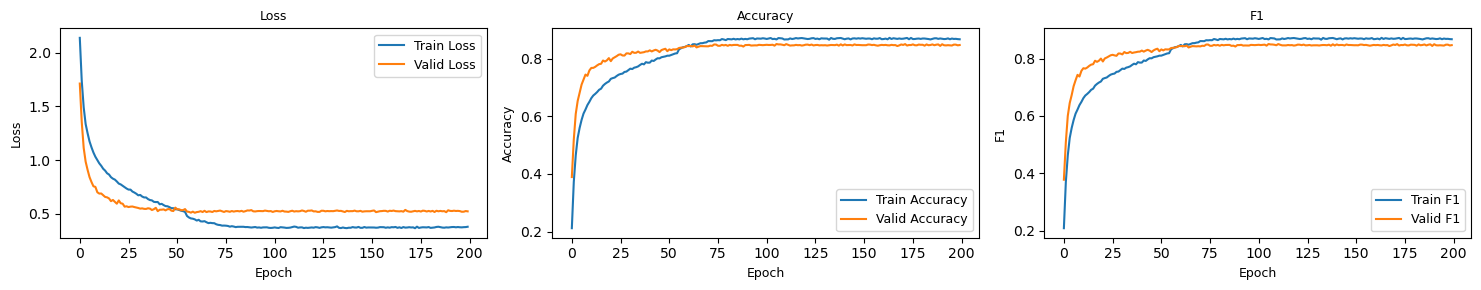

../../dataset/CIFAKE/models/ResNet/realmodel_105.pt


In [36]:
model_name = 'ResNet'
setting = 'real'
model = ResNet50Model(num_class)

model_save_directory = f"../../dataset/CIFAKE/models/{model_name}/{setting}"
utils.create_directory(model_save_directory)
utils.delete_subfolders(model_save_directory)

num_epochs = 200
lr = 1e-2
trainer = CNNModelTrainer()
best_val_file = trainer.train(model, train_loader_r, valid_loader_r, model_save_directory, num_epochs=num_epochs, lr=lr)

In [38]:
model = ResNet50Model(num_class)
model.load_state_dict(torch.load(best_val_file))

<All keys matched successfully>

In [43]:
display = True
out_filepath = None
trainer = CNNModelTrainer()
preds, test_outputs = trainer.evaluate(model, test_loader_r, display, out_filepath)
df_test_r['preds'] = preds
df_test_r.to_csv(f'{root}/results/{model_name}_{setting}_real.csv', index=False)

              precision  recall  f1-score     support
0              0.856046  0.8920  0.873653   1000.0000
1              0.920762  0.9180  0.919379   1000.0000
2              0.812438  0.8230  0.817685   1000.0000
3              0.697190  0.6700  0.683325   1000.0000
4              0.836344  0.7870  0.810922   1000.0000
5              0.747379  0.7130  0.729785   1000.0000
6              0.862669  0.8920  0.877089   1000.0000
7              0.866080  0.8860  0.875927   1000.0000
8              0.910244  0.9330  0.921481   1000.0000
9              0.884158  0.8930  0.888557   1000.0000
accuracy       0.840700  0.8407  0.840700      0.8407
macro avg      0.839331  0.8407  0.839780  10000.0000
weighted avg   0.839331  0.8407  0.839780  10000.0000


/tmp/ipykernel_153861/2632353331.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_r['preds'] = preds


In [44]:
display = True
out_filepath = None
trainer = CNNModelTrainer()
preds, test_outputs = trainer.evaluate(model, test_loader_f, display, out_filepath)
df_test_f['preds'] = preds
df_test_f.to_csv(f'{root}/results/{model_name}_{setting}_fake.csv', index=False)

              precision  recall  f1-score     support
0              0.562811  0.9050  0.694018   1000.0000
1              0.813333  0.8540  0.833171   1000.0000
2              0.664317  0.7540  0.706323   1000.0000
3              0.674882  0.7120  0.692944   1000.0000
4              0.884937  0.8460  0.865031   1000.0000
5              0.708229  0.5680  0.630411   1000.0000
6              0.919149  0.6480  0.760117   1000.0000
7              0.886443  0.7650  0.821256   1000.0000
8              0.842217  0.7900  0.815273   1000.0000
9              0.902027  0.8010  0.848517   1000.0000
accuracy       0.764300  0.7643  0.764300      0.7643
macro avg      0.785835  0.7643  0.766706  10000.0000
weighted avg   0.785835  0.7643  0.766706  10000.0000


/tmp/ipykernel_153861/768725313.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_f['preds'] = preds


# Fake

../../dataset/CIFAKE/models/ResNet/fake created.
Sub folders of ../../dataset/CIFAKE/models/ResNet/fake was deleted.
Epoch: 0 | Validation Accuracy: 0.6846 | Loss: 0.8987 | F1: 0.6808
Epoch: 1 | Validation Accuracy: 0.8188 | Loss: 0.5336 | F1: 0.8188
Epoch: 2 | Validation Accuracy: 0.8622 | Loss: 0.4015 | F1: 0.8615
Epoch: 3 | Validation Accuracy: 0.8855 | Loss: 0.3324 | F1: 0.8851
Epoch: 4 | Validation Accuracy: 0.9034 | Loss: 0.2824 | F1: 0.9032
Epoch: 5 | Validation Accuracy: 0.9139 | Loss: 0.2502 | F1: 0.9136
Epoch: 6 | Validation Accuracy: 0.9146 | Loss: 0.2542 | F1: 0.9148
Epoch: 7 | Validation Accuracy: 0.9251 | Loss: 0.2177 | F1: 0.9253
Epoch: 8 | Validation Accuracy: 0.9262 | Loss: 0.2170 | F1: 0.9263
Epoch: 9 | Validation Accuracy: 0.9366 | Loss: 0.1883 | F1: 0.9367
Epoch: 10 | Validation Accuracy: 0.9335 | Loss: 0.1904 | F1: 0.9334
Epoch: 11 | Validation Accuracy: 0.9400 | Loss: 0.1788 | F1: 0.9402
Epoch: 12 | Validation Accuracy: 0.9393 | Loss: 0.1746 | F1: 0.9396
Epoch: 13

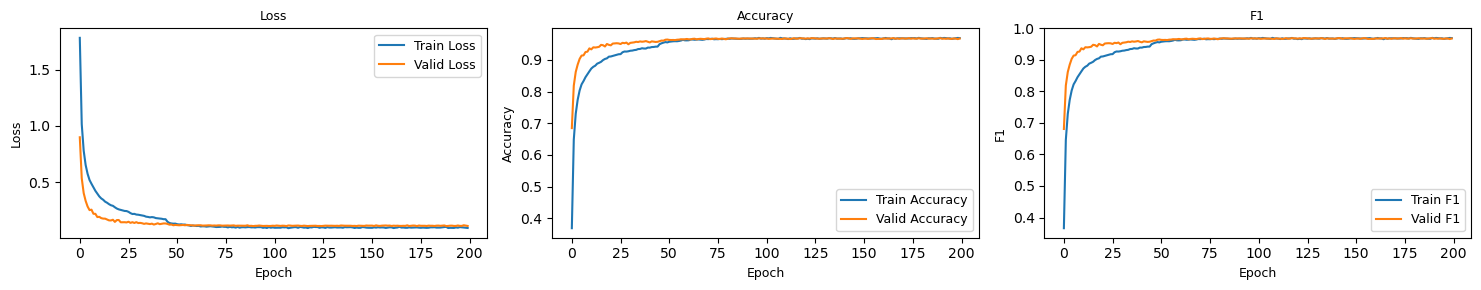

../../dataset/CIFAKE/models/ResNet/fakemodel_141.pt


In [45]:
model_name = 'ResNet'
setting = 'fake'
model = ResNet50Model(num_class)

model_save_directory = f"../../dataset/CIFAKE/models/{model_name}/{setting}"
utils.create_directory(model_save_directory)
utils.delete_subfolders(model_save_directory)

num_epochs = 200
lr = 1e-2
trainer = CNNModelTrainer()
best_val_file = trainer.train(model, train_loader_f, valid_loader_f, model_save_directory, num_epochs=num_epochs, lr=lr)

In [46]:
model = ResNet50Model(num_class)
model.load_state_dict(torch.load(best_val_file))

<All keys matched successfully>

In [47]:
display = True
out_filepath = None
trainer = CNNModelTrainer()
preds, test_outputs = trainer.evaluate(model, test_loader_r, display, out_filepath)
df_test_r['preds'] = preds
df_test_r.to_csv(f'{root}/results/{model_name}_{setting}_real.csv', index=False)

              precision  recall  f1-score     support
0              0.827011  0.5450  0.657022   1000.0000
1              0.854257  0.5920  0.699350   1000.0000
2              0.370083  0.6210  0.463779   1000.0000
3              0.369276  0.5000  0.424809   1000.0000
4              0.547859  0.4350  0.484950   1000.0000
5              0.498188  0.5500  0.522814   1000.0000
6              0.545977  0.0950  0.161840   1000.0000
7              0.619776  0.6080  0.613831   1000.0000
8              0.764350  0.7590  0.761666   1000.0000
9              0.547134  0.8590  0.668482   1000.0000
accuracy       0.556400  0.5564  0.556400      0.5564
macro avg      0.594391  0.5564  0.545854  10000.0000
weighted avg   0.594391  0.5564  0.545854  10000.0000


/tmp/ipykernel_153861/2632353331.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_r['preds'] = preds


In [48]:
display = True
out_filepath = None
trainer = CNNModelTrainer()
preds, test_outputs = trainer.evaluate(model, test_loader_f, display, out_filepath)
df_test_f['preds'] = preds
df_test_f.to_csv(f'{root}/results/{model_name}_{setting}_fake.csv', index=False)

              precision  recall  f1-score     support
0              0.940777  0.9690  0.954680   1000.0000
1              0.987952  0.9840  0.985972   1000.0000
2              0.962777  0.9570  0.959880   1000.0000
3              0.953061  0.9340  0.943434   1000.0000
4              0.994970  0.9890  0.991976   1000.0000
5              0.936024  0.9510  0.943452   1000.0000
6              0.993007  0.9940  0.993503   1000.0000
7              0.980119  0.9860  0.983051   1000.0000
8              0.968432  0.9510  0.959637   1000.0000
9              0.981019  0.9820  0.981509   1000.0000
accuracy       0.969700  0.9697  0.969700      0.9697
macro avg      0.969814  0.9697  0.969709  10000.0000
weighted avg   0.969814  0.9697  0.969709  10000.0000


/tmp/ipykernel_153861/768725313.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_f['preds'] = preds
